# 03 — Randomisation diagnostics

**Purpose.** Decide whether the differences found in Feature 2 can be interpreted
causally *at all*, before spending any effort testing them.

Feature 2 showed both email arms beating control on every outcome. That comparison
is only meaningful if the arms were comparable to begin with. Randomisation is
supposed to guarantee that — but a design's intent and a dataset's reality are
different things, and the gap between them is where broken experiments hide.

Three checks, in increasing order of strength:

| Check | Question | Catches |
|---|---|---|
| Sample ratio mismatch | Did each arm get the intended number of customers? | Broken assignment or logging |
| Covariate balance | Are the arms comparable on each pre-treatment attribute? | Imbalance in a single variable |
| Omnibus balance | Do the covariates *jointly* predict assignment? | Multivariate imbalance the per-variable scan misses |

**This notebook is capable of failing.** If it did, the honest conclusion would be
that Features 4-12 should not be run. It is worth knowing that before reading the
results.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.data.load import load_processed
from src.analysis.diagnostics import (
    srm_test,
    covariate_balance,
    omnibus_balance_test,
)

pd.set_option("display.width", 120)
df = load_processed()
print(f"{len(df):,} customers across {df[config.TREATMENT_COL].nunique()} arms")

64,000 customers across 3 arms


## 1. Sample ratio mismatch

The experiment was designed as an equal three-way split. A chi-square
goodness-of-fit test asks whether the observed allocation is consistent with that.

This is run as **one omnibus test over all three arms**, not three pairwise tests.
The question is whether the allocation as a whole departs from the design, and
splitting it into pairs would both misstate the question and multiply the false
positive rate.

In [2]:
srm = srm_test(df)

srm.to_frame().style.format({
    "observed": "{:,.0f}",
    "expected": "{:,.1f}",
    "difference": "{:+,.1f}",
    "share": "{:.4%}",
})

,observed,expected,difference,share
segment,,,,
No E-Mail,"21,306","21,333.3",-27.3,33.2906%
Mens E-Mail,"21,307","21,333.3",-26.3,33.2922%
Womens E-Mail,"21,387","21,333.3",+53.7,33.4172%


In [3]:
print(f"chi-square = {srm.chi2:.4f}   dof = {srm.dof}   p = {srm.p_value:.4f}")
print(f"alpha      = {srm.alpha}")
print()
print(srm.verdict)

chi-square = 0.2025   dof = 2   p = 0.9037
alpha      = 0.001

No sample ratio mismatch (p = 0.904). The arm sizes are consistent with the intended split.


### Why alpha = 0.001 and not 0.05

An SRM invalidates an entire experiment, so the test is deliberately hard to
trigger. At the conventional 0.05, one healthy experiment in twenty would be
condemned by chance — and a diagnostic that cries wolf that often stops being acted
on. 0.001 is the level used in the industry literature on SRM diagnosis.

Here it makes no difference: **p = 0.90**. The arms differ by at most 54 customers
out of ~21,300, comfortably within what an equal-probability coin flip produces.

## 2. Covariate balance

Randomisation makes the arms comparable *in expectation*. Any single randomisation
still deals a particular hand, and it is worth looking at the hand that was dealt.

For each pre-treatment covariate, compare its distribution between one email arm and
control. Categoricals are expanded into one 0/1 indicator per level, which lets a
single **standardised mean difference** formula apply to everything — for a 0/1
indicator the variance is just p(1-p), so the continuous formula reduces to the
proportion formula rather than needing a special case.

In [4]:
balance = pd.concat(
    [covariate_balance(df, arm, control) for arm, control in config.COMPARISONS],
    ignore_index=True,
)

print(f"{len(balance)} covariate comparisons "
      f"({balance['covariate'].nunique()} covariates, expanded to levels)")
print()
balance.nlargest(10, "abs_smd")[
    ["treatment_arm", "covariate", "level", "treated_mean", "control_mean",
     "smd", "p_value"]
].style.format({
    "treated_mean": "{:.4f}",
    "control_mean": "{:.4f}",
    "smd": "{:+.4f}",
    "p_value": "{:.3f}",
}).hide(axis="index")

36 covariate comparisons (8 covariates, expanded to levels)



treatment_arm,covariate,level,treated_mean,control_mean,smd,p_value
Mens E-Mail,history_segment,2) $100 - $200,0.2202,0.2270,-0.0164,0.091
Mens E-Mail,history_segment,"7) $1,000 +",0.0218,0.0195,+0.0158,0.102
Womens E-Mail,history_segment,2) $100 - $200,0.2210,0.2270,-0.0143,0.140
Mens E-Mail,zip_code,Rural,0.1522,0.1473,+0.0137,0.159
Mens E-Mail,zip_code,Surburban,0.4459,0.4518,-0.0117,0.225
Womens E-Mail,history_segment,3) $200 - $350,0.1943,0.1898,+0.0114,0.241
Mens E-Mail,channel,Web,0.4454,0.4399,+0.0110,0.256
Mens E-Mail,history_segment,1) $0 - $100,0.3625,0.3573,+0.0109,0.260
Mens E-Mail,history_segment,5) $500 - $750,0.0750,0.0775,-0.0097,0.315
Womens E-Mail,history_segment,"6) $750 - $1,000",0.0277,0.0292,-0.0088,0.362


### Why both an SMD and a p-value

They answer different questions, and at this sample size they can disagree in a way
that matters:

- The **SMD** says *how large* an imbalance is. It is unitless, so `history` in
  dollars and `newbie` as a 0/1 flag land on the same scale and can be read against
  one threshold (0.1, the conventional cutoff).
- The **p-value** says *how surely the imbalance is not exactly zero*. With ~21,000
  customers per arm, an imbalance far too small to matter can still be statistically
  significant.

So the SMD is the decision-relevant number and the p-value is context. Reporting only
the p-value at this sample size is how a trivial imbalance gets treated as a problem.

In [5]:
largest = balance["abs_smd"].max()
above_threshold = (~balance["balanced"]).sum()
significant = (balance["p_value"] < config.ALPHA).sum()

print(f"Largest |SMD| across all comparisons : {largest:.4f}")
print(f"Threshold                            : {config.SMD_THRESHOLD}")
print(f"Covariates above threshold           : {above_threshold} of {len(balance)}")
print()
print(f"Balance tests with p < {config.ALPHA}           : {significant} of {len(balance)}")
print(f"Expected by chance alone             : ~{config.ALPHA * len(balance):.1f}")

Largest |SMD| across all comparisons : 0.0164
Threshold                            : 0.1
Covariates above threshold           : 0 of 36

Balance tests with p < 0.05           : 0 of 36
Expected by chance alone             : ~1.8


**Largest imbalance is 0.016 — about a sixth of the threshold.** Nothing is close
to problematic.

The p-value line is worth reading carefully. Zero of 36 tests are significant, where
roughly 1.8 would be expected by chance if every null were true. That is *fewer* than
expected, but it is not evidence of anything: the 36 tests are not independent, since
the indicator levels within a categorical covariate are constrained to sum to one.

The reasoning to internalise is the reverse case. Had two or three tests come back
significant, that would have been **the expected outcome of running 36 tests**, not a
discovery. Treating those as broken randomisation is a classic multiple-comparisons
error — and the SMD column is what keeps the decision anchored to effect size instead.

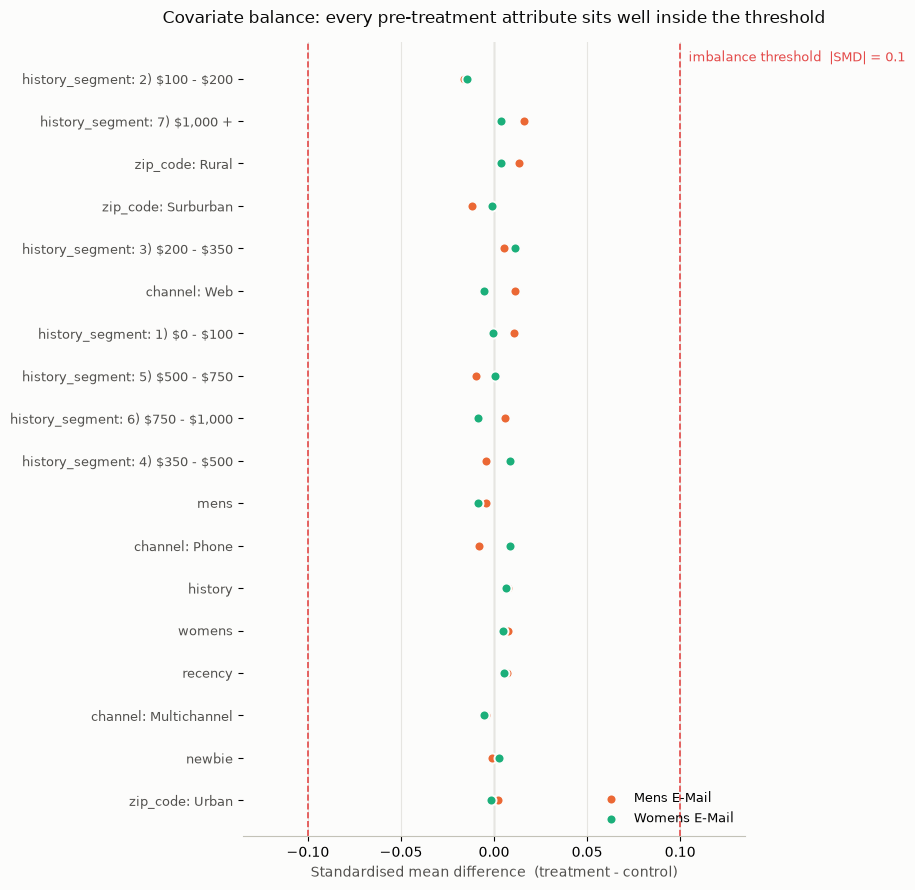

In [6]:
# Love plot: the standard way to present covariate balance.
# Colour follows the arm, matching the palette used throughout the project.
ARM_COLOURS = {"Mens E-Mail": "#eb6834", "Womens E-Mail": "#1baf7a"}

plot_data = balance.copy()
plot_data["label"] = [
    covariate if not level else f"{covariate}: {level}"
    for covariate, level in zip(plot_data["covariate"], plot_data["level"])
]
# Matplotlib reads $...$ as LaTeX math mode, which would silently swallow the
# dollar signs in the history_segment band labels.
plot_data["label"] = plot_data["label"].str.replace("$", r"\$", regex=False)
order = (
    plot_data.groupby("label")["abs_smd"].max().sort_values().index.tolist()
)
positions = {label: i for i, label in enumerate(order)}

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

for arm, colour in ARM_COLOURS.items():
    subset = plot_data[plot_data["treatment_arm"] == arm]
    ax.scatter(
        subset["smd"], [positions[l] for l in subset["label"]],
        s=52, color=colour, label=arm, zorder=3,
        edgecolor="#fcfcfb", linewidth=1.4,   # 2px surface ring on overlap
    )

ax.axvline(0, color="#c3c2b7", linewidth=1, zorder=1)
for threshold in (-config.SMD_THRESHOLD, config.SMD_THRESHOLD):
    ax.axvline(threshold, color="#e34948", linewidth=1.2, linestyle="--", zorder=2)
ax.annotate(
    f"imbalance threshold  |SMD| = {config.SMD_THRESHOLD}",
    (config.SMD_THRESHOLD, len(order) - 0.5),
    xytext=(6, 0), textcoords="offset points",
    fontsize=9, color="#e34948", va="center",
)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9, color="#52514e")
ax.set_xlim(-config.SMD_THRESHOLD * 1.35, config.SMD_THRESHOLD * 1.35)
ax.set_xlabel("Standardised mean difference  (treatment - control)",
              fontsize=10, color="#52514e")
ax.set_title(
    "Covariate balance: every pre-treatment attribute sits well inside the threshold",
    fontsize=12, color="#0b0b0b", pad=14,
)
ax.grid(axis="x", color="#e6e5e1", linewidth=0.8, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.legend(frameon=False, fontsize=9, loc="lower right")

fig.tight_layout()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "03_covariate_balance.png", dpi=150, bbox_inches="tight",
            facecolor="#fcfcfb")
plt.show()

Every point sits far inside the dashed threshold. The axis is scaled to the
threshold rather than to the data, so the emptiness is the finding — zoom the axis to
the data and a 0.016 imbalance would look dramatic.

## 3. Omnibus balance

Per-covariate checks have a blind spot: several individually-negligible imbalances
can combine into a meaningful one. The stronger test asks whether the covariates
**jointly** predict treatment assignment.

Fit a logistic regression of the treatment indicator on every pre-treatment
covariate, and compare it to an intercept-only model by likelihood-ratio test. Under
valid randomisation the covariates carry no information about who was treated, so the
model should be no better than the intercept.

In [7]:
results = [omnibus_balance_test(df, arm, control)
           for arm, control in config.COMPARISONS]

summary = pd.DataFrame([{
    "treatment arm": r.treatment_arm,
    "n": r.n,
    "LR statistic": r.llr_statistic,
    "dof": r.dof,
    "p-value": r.p_value,
    "pseudo-R2": r.pseudo_r2,
} for r in results])

summary.style.format({
    "n": "{:,}",
    "LR statistic": "{:.3f}",
    "p-value": "{:.4f}",
    "pseudo-R2": "{:.6f}",
}).hide(axis="index")

treatment arm,n,LR statistic,dof,p-value,pseudo-R2
Mens E-Mail,"42,613",13.242,15,0.5836,0.000224
Womens E-Mail,"42,693",11.275,15,0.7329,0.000190


In [8]:
for r in results:
    print(r.verdict)
    print()

Covariates do not jointly predict assignment to Mens E-Mail (p = 0.584, pseudo-R2 = 0.00022). Consistent with valid randomisation.

Covariates do not jointly predict assignment to Womens E-Mail (p = 0.733, pseudo-R2 = 0.00019). Consistent with valid randomisation.



**The pseudo-R² is the number to look at, more than the p-value.** It says how much
of the assignment is explained at all: 0.0002, meaning the sixteen covariates jointly
account for roughly **two hundredths of one percent** of the variation in who received
an email. Assignment is, for practical purposes, unpredictable from anything known
beforehand — which is exactly what randomisation is supposed to produce.

A p-value alone could not make that statement. It would only say "not distinguishable
from zero", and at n = 42,000 a genuinely tiny effect would still be detectable. The
effect size says the covariates are uninformative, not merely that we failed to prove
otherwise.

## 4. Does the diagnostic actually work?

Every check above passed, which raises a fair question: would these tests catch a
problem, or do they pass on anything?

Below, treatment is deliberately reassigned as a function of `recency` — recent
purchasers are sent to the Mens arm with probability 0.8, everyone else with
probability 0.2. This is the exact failure randomisation exists to prevent.

In [9]:
import numpy as np

rng = np.random.default_rng(config.RANDOM_SEED)
confounded = df.copy()
probability = np.where(confounded["recency"] <= 4, 0.8, 0.2)
confounded[config.TREATMENT_COL] = pd.Categorical(
    np.where(rng.random(len(confounded)) < probability,
             config.MENS_ARM, config.CONTROL_ARM),
    categories=[config.CONTROL_ARM, config.MENS_ARM, config.WOMENS_ARM],
)

broken_balance = covariate_balance(confounded, config.MENS_ARM)
broken_omnibus = omnibus_balance_test(confounded, config.MENS_ARM)

print("On the deliberately confounded experiment:")
print(f"  recency |SMD|        : "
      f"{broken_balance.loc[broken_balance.covariate == 'recency', 'abs_smd'].iloc[0]:.3f}"
      f"   (real experiment: "
      f"{balance.loc[balance.covariate == 'recency', 'abs_smd'].max():.3f})")
print(f"  covariates flagged   : {(~broken_balance['balanced']).sum()} of {len(broken_balance)}")
print(f"  omnibus pseudo-R2    : {broken_omnibus.pseudo_r2:.4f}"
      f"   (real experiment: {results[0].pseudo_r2:.6f})")
print(f"  omnibus p-value      : {broken_omnibus.p_value:.2e}")
print()
print(broken_omnibus.verdict)

On the deliberately confounded experiment:
  recency |SMD|        : 1.215   (real experiment: 0.007)
  covariates flagged   : 7 of 18
  omnibus pseudo-R2    : 0.2132   (real experiment: 0.000224)
  omnibus p-value      : 0.00e+00

Covariates DO jointly predict assignment to Mens E-Mail (p = 0.0000). Investigate the assignment mechanism before interpreting effects.


The diagnostics fire hard. The recency imbalance is **1.22** against a 0.1
threshold, 7 of 18 covariates are flagged, and the omnibus pseudo-R² jumps from
0.0002 to 0.21 — roughly **950x**. These checks discriminate; the clean result on
the real data is informative rather than vacuous.

This is also what the test suite asserts, so the property is enforced rather than
demonstrated once here.

## Verdict

| Check | Result | Interpretation |
|---|---|---|
| Sample ratio mismatch | p = 0.90 | Arm sizes match the intended equal split |
| Covariate balance | max \|SMD\| = 0.016 | Every covariate far inside the 0.1 threshold |
| Omnibus balance | pseudo-R² = 0.0002 | Covariates jointly explain ~0% of assignment |

**The randomisation is sound.** Differences in outcomes between arms can be
attributed to the emails rather than to pre-existing differences between the
customers who received them.

One thing this does *not* establish: that the experiment was large enough to detect
the effects we care about. Balance is about bias; sample size is about variance, and
Feature 2 already flagged that spend carries a standard deviation ~14x its mean.

**Next — Feature 4:** estimate the treatment effects properly, with confidence
intervals and a correction for testing three outcomes across two arms.